In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, GroupKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import xgboost as xgb
from sklearn.preprocessing import TargetEncoder 
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
import lime
import lime.lime_tabular
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.base import is_regressor


In [3]:
# 1. Cargar y preparar datos
df = pd.read_csv("california_accidents_cleaned.csv", parse_dates=['year_week'])
df[['start_date_str', 'end_date_str']] = df['year_week'].str.split('/', expand=True)
df['start_date'] = pd.to_datetime(df['start_date_str'])
df['year'] = df['start_date'].dt.isocalendar().year
df['week'] = df['start_date'].dt.isocalendar().week
df.drop(['start_date_str', 'end_date_str'], axis=1, inplace=True)

C:\Users\Sara\AppData\Local\Temp\ipykernel_18992\1061881644.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("california_accidents_cleaned.csv", parse_dates=['year_week'])


In [4]:
X = df.drop(['accident_count', 'zone_week_id', 'year_week'], axis=1)
y = df['accident_count']
groups = df['zone_id']
time_series = df['year'] * 100 + df['week']

In [5]:
# Ordenar por fecha (aseguramos orden temporal)
sorted_idx = np.argsort(time_series)
X_sorted = X.iloc[sorted_idx]
y_sorted = y.iloc[sorted_idx]
groups_sorted = groups.iloc[sorted_idx]

In [6]:
# Dividir 75% entrenamiento / 25% test
n_train = int(0.75 * len(X_sorted))
X_train, X_test = X_sorted.iloc[:n_train], X_sorted.iloc[n_train:]
y_train, y_test = y_sorted.iloc[:n_train], y_sorted.iloc[n_train:]
groups_train = groups_sorted.iloc[:n_train]  # <-- groups original

# Preprocesamiento: eliminar NaN y actualizar grupos
X_train = X_train.dropna(subset=["Temperature(F)", "Wind_Speed(mph)", "Humidity(%)"])
y_train = y_train.loc[X_train.index]
groups_train = groups_train.loc[X_train.index]  # <-- ¡Actualizar grupos!

In [7]:
df["Precipitation(in)"] = pd.to_numeric(df["Precipitation(in)"], errors='coerce')

In [8]:
# 2. Preprocesamiento
numerical_features = [
    "Temperature(F)", "Wind_Speed(mph)", "Precipitation(in)", "Humidity(%)",
    "Start_Lat", "Start_Lng"
]
categorical_features = [
    "zone_id"
]
count_features = [
    "Junction", "Railway", "Roundabout", "Station", "Stop", "Traffic_Signal",
    "Temperature(F)_extreme", "Wind_Speed(mph)_extreme", "Precipitation(in)_extreme",
    "Humidity(%)_extreme", "is_night", "is_weekend"
]

In [9]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), 
        ('scaler', StandardScaler())
    ]), ["Temperature(F)", "Wind_Speed(mph)", "Humidity(%)", "Start_Lat", "Start_Lng"]),
    
    # Imputar Precipitation(in) por separado con 0
    ('precipitation', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),  # <-- ¡Nueva!
        ('scaler', StandardScaler())
    ]), ["Precipitation(in)"]),
    
    ('cat', TargetEncoder(target_type='continuous'), ["zone_id"]),
    ('count', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),  
    ]), count_features)
])

In [10]:
# 3. Modelos y grids
pipelines = {
    'knn': Pipeline([('preprocessor', preprocessor), ('model', KNeighborsRegressor())]),
    'ridge': Pipeline([('preprocessor', preprocessor), ('model', Ridge(random_state=42))]),
    'lasso': Pipeline([('preprocessor', preprocessor), ('model', Lasso(random_state=42, max_iter=10000))]),
    'random_forest': Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
    'xgboost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBRegressor(
            random_state=42,
            objective='reg:squarederror',
            tree_method='hist',  
            predictor='cpu_predictor'
        ))
    ]),
    'svr': Pipeline([('preprocessor', preprocessor), ('model', SVR())]) 
}

In [11]:
param_grids = {
    'knn': {'model__n_neighbors': [3, 5], 'model__weights': ['uniform', 'distance']},
    'ridge': {'model__alpha': [0.1, 1.0]},
    'lasso': {'model__alpha': [0.1, 1.0]},
    'random_forest': {'model__n_estimators': [100], 'model__max_depth': [None, 10]},
    'xgboost': {'model__max_depth': [3], 'model__learning_rate': [0.1], 'model__n_estimators': [100]},
    'svr': {  # Grid para SVR
        'model__C': [0.1, 1, 10],           # Parámetro de regularización
        'model__epsilon': [0.1, 0.2],       # Margen de error permitido
        'model__kernel': ['linear', 'rbf']   # Tipo de kernel
    }
}

In [12]:
# 4. Validación cruzada
tscv = TimeSeriesSplit(n_splits=3)
group_kfold = GroupKFold(n_splits=3)
scorer = make_scorer(root_mean_squared_error, squared=False)

In [13]:
# 5. Resultados
results = []

In [14]:
X_train_preprocessed = preprocessor.fit_transform(X_train, y_train)
print("¿Tiene NaNs después del preprocesamiento?", np.isnan(X_train_preprocessed).any())


¿Tiene NaNs después del preprocesamiento? False


In [15]:
print("NaN después de todas las correcciones:")
print(X_train.isna().sum().sum())  # Debe ser 0

NaN después de todas las correcciones:
45074


In [16]:
print("Columnas X_train:", X_train.columns.tolist())
print("Keys param_grid:", param_grids.keys())


Columnas X_train: ['Temperature(F)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Humidity(%)', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'Temperature(F)_extreme', 'Wind_Speed(mph)_extreme', 'Precipitation(in)_extreme', 'Humidity(%)_extreme', 'is_night', 'is_weekend', 'Start_Lat', 'Start_Lng', 'zone_id', 'lat_bin', 'lng_bin', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'start_date', 'year', 'week']
Keys param_grid: dict_keys(['knn', 'ridge', 'lasso', 'random_forest', 'xgboost', 'svr'])



Optimizando KNN


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
  - Train RMSE: 6.53, MAE: 3.80, R2: 0.38
  - Test  RMSE: 6.09, MAE: 3.53, R2: 0.42


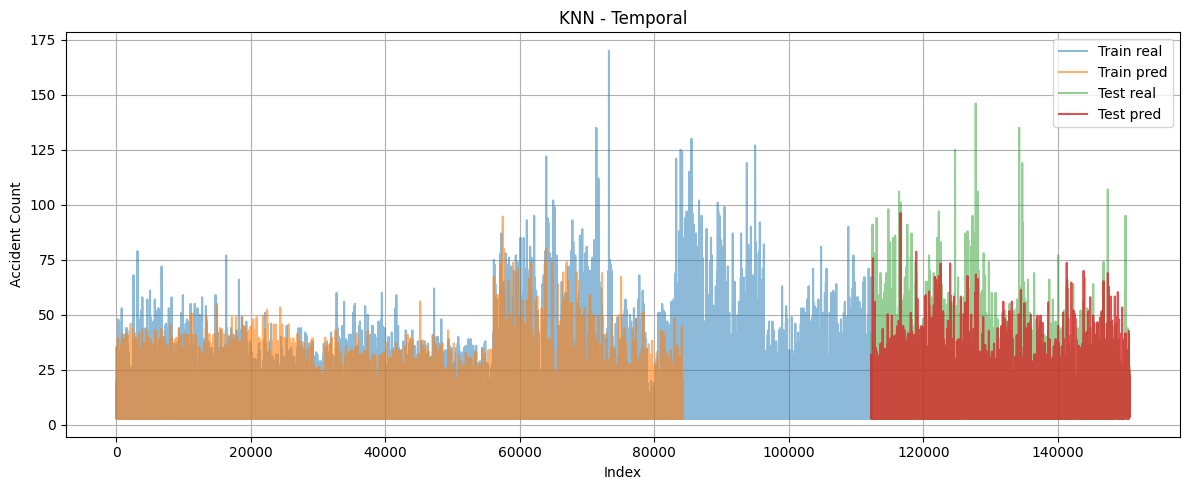

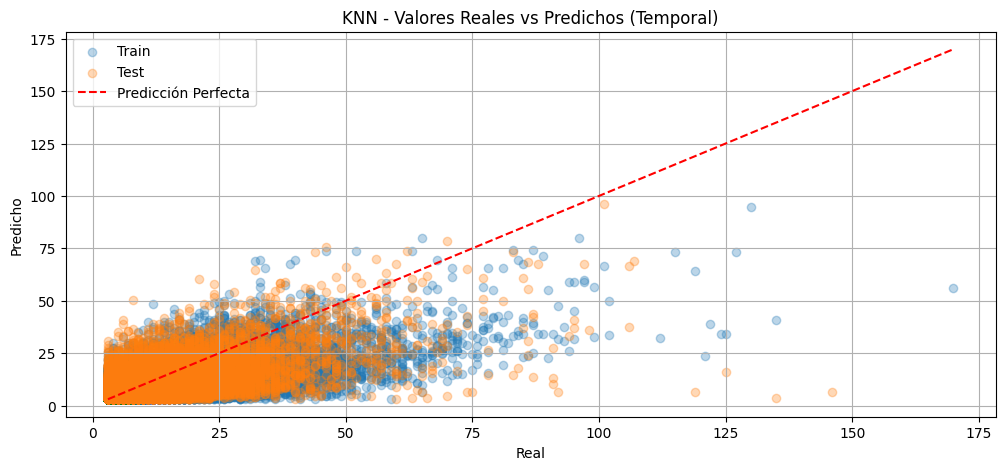

<Figure size 1200x400 with 0 Axes>

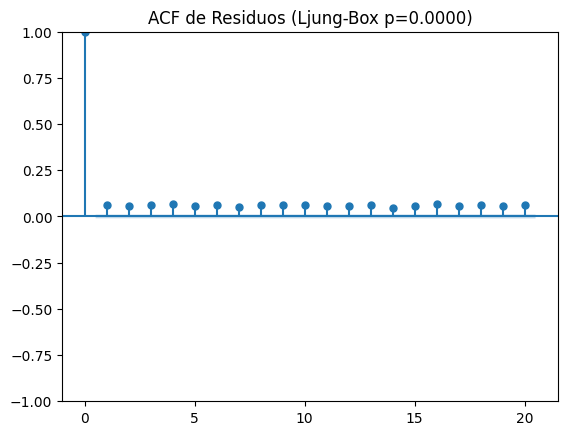

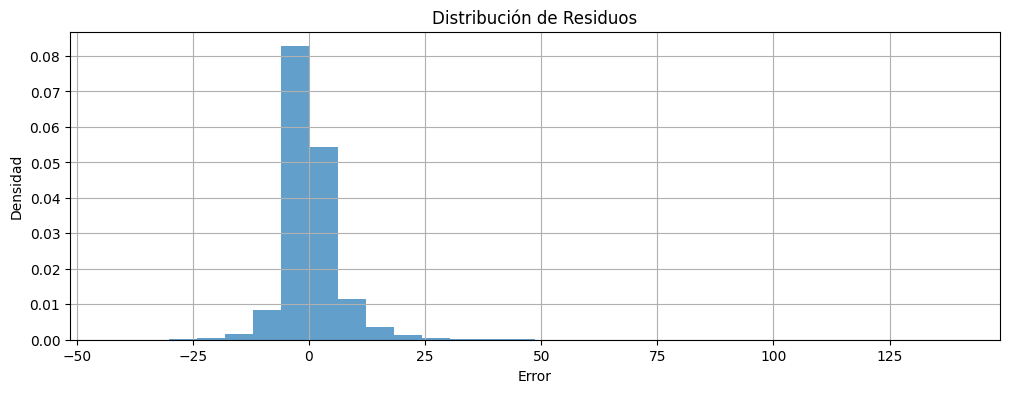

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
  - Train RMSE: 7.63, MAE: 4.61, R2: 0.04
  - Test  RMSE: 6.07, MAE: 3.50, R2: 0.43


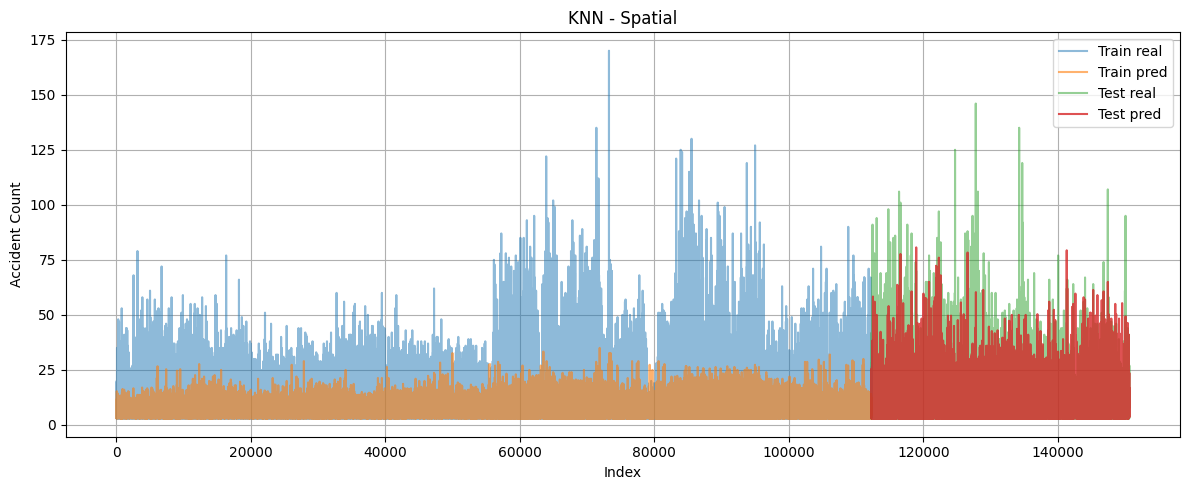

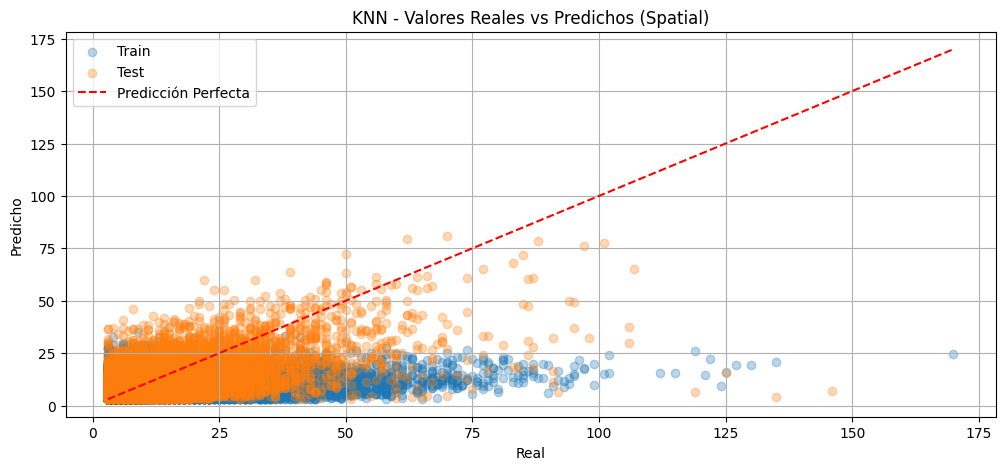

<Figure size 1200x400 with 0 Axes>

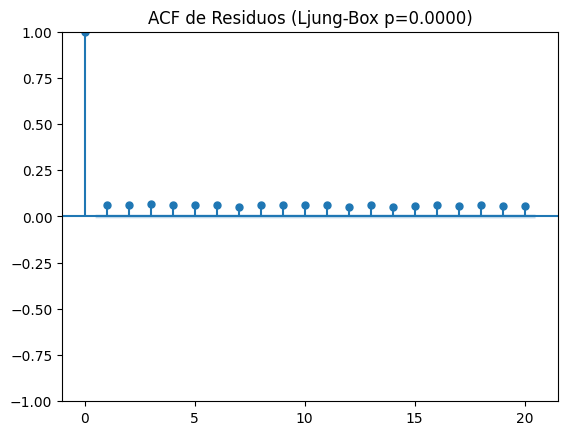

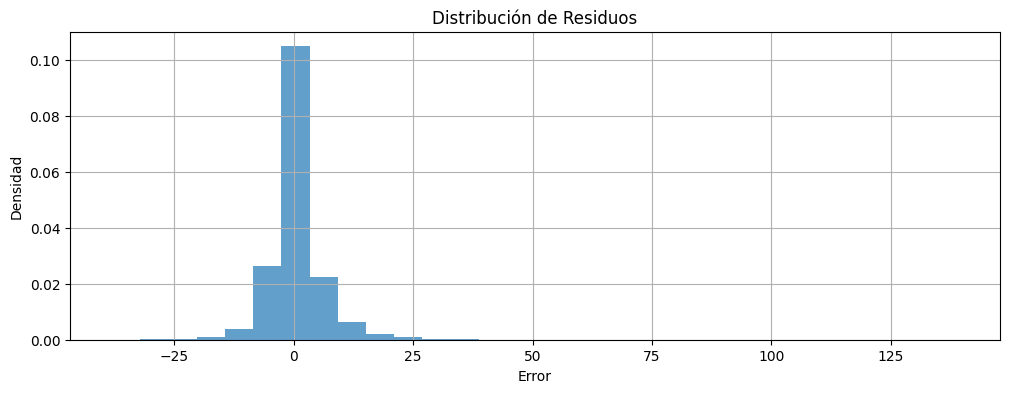


Optimizando RIDGE


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 3.55, MAE: 2.25, R2: 0.82
  - Test  RMSE: 4.03, MAE: 2.40, R2: 0.75


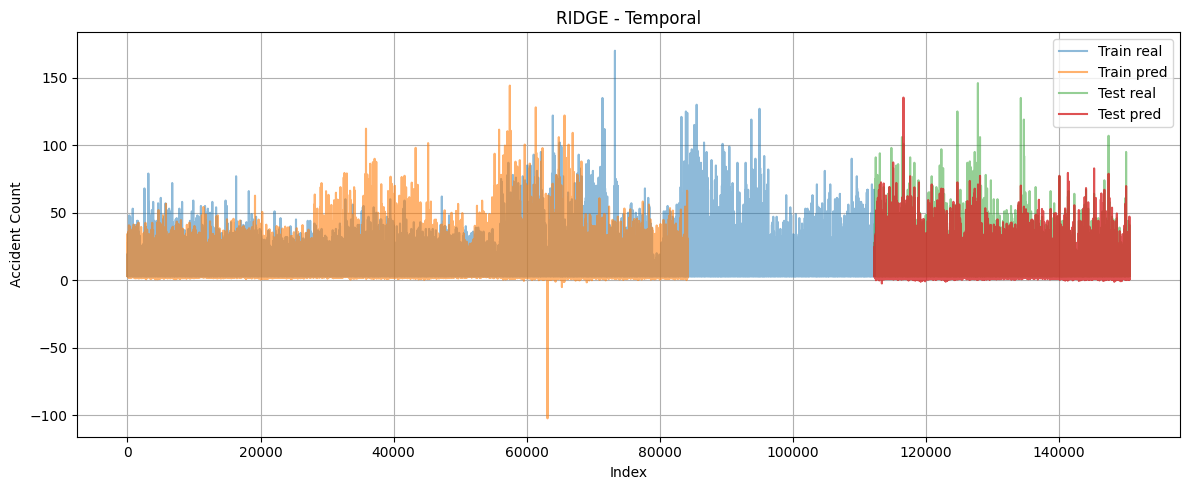

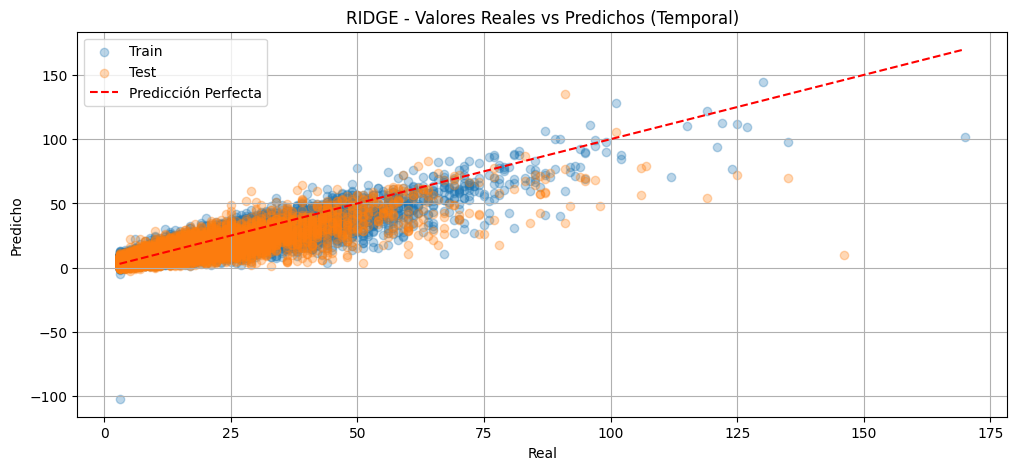

<Figure size 1200x400 with 0 Axes>

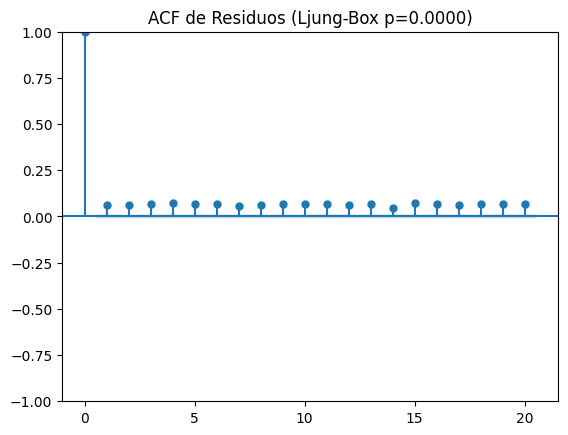

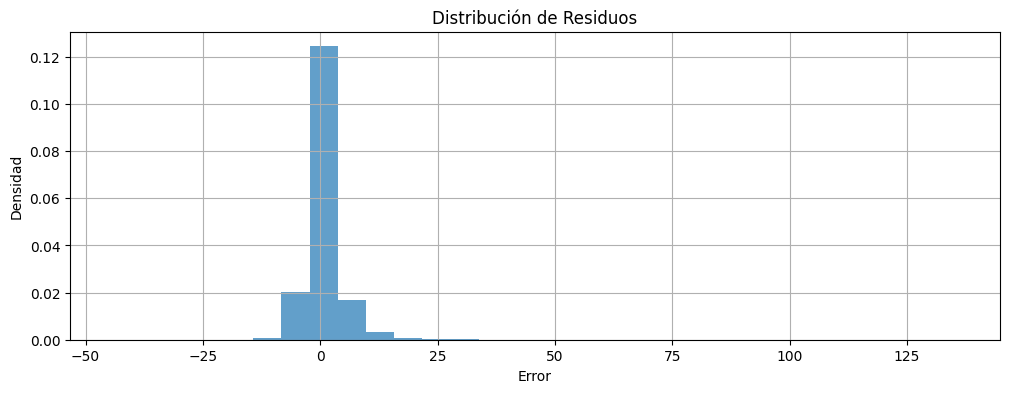

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 3.67, MAE: 2.45, R2: 0.78
  - Test  RMSE: 4.03, MAE: 2.40, R2: 0.75


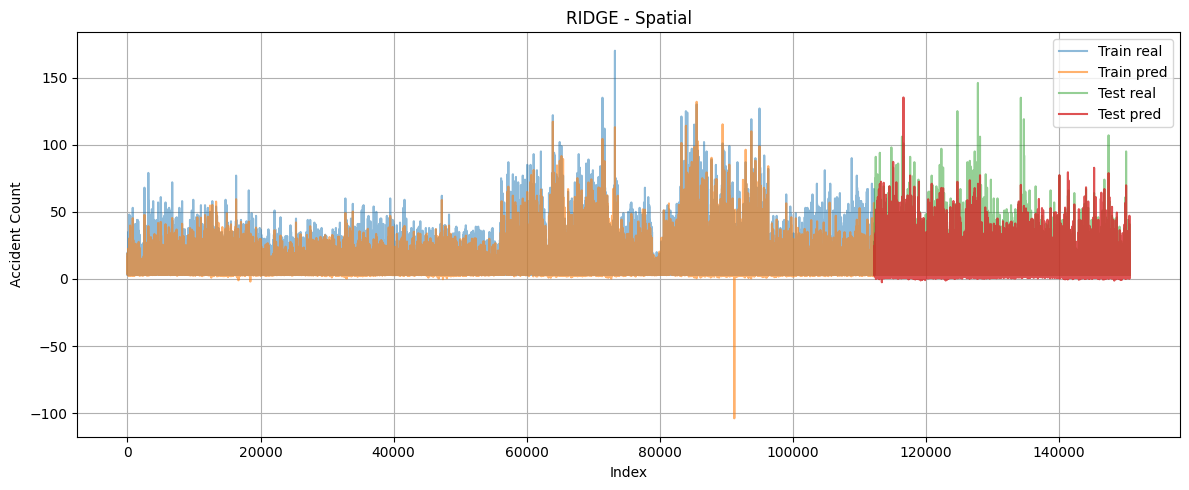

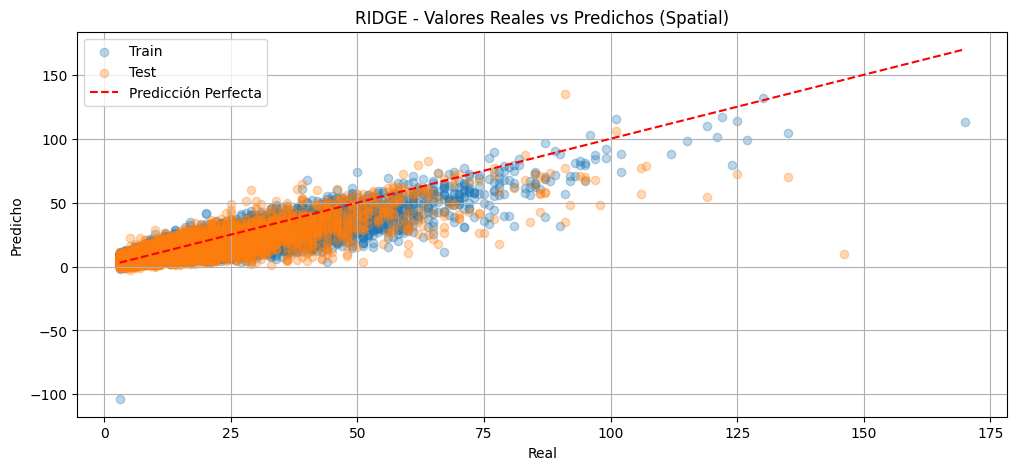

<Figure size 1200x400 with 0 Axes>

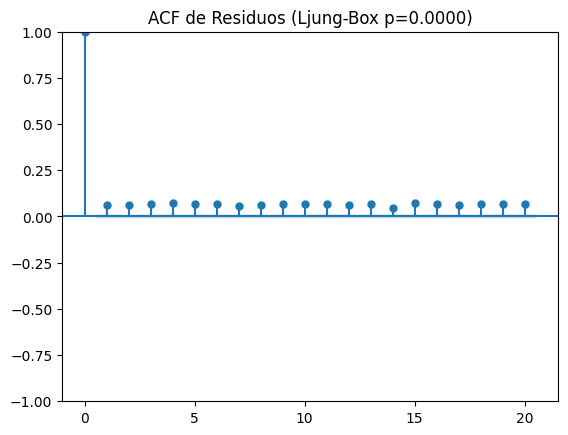

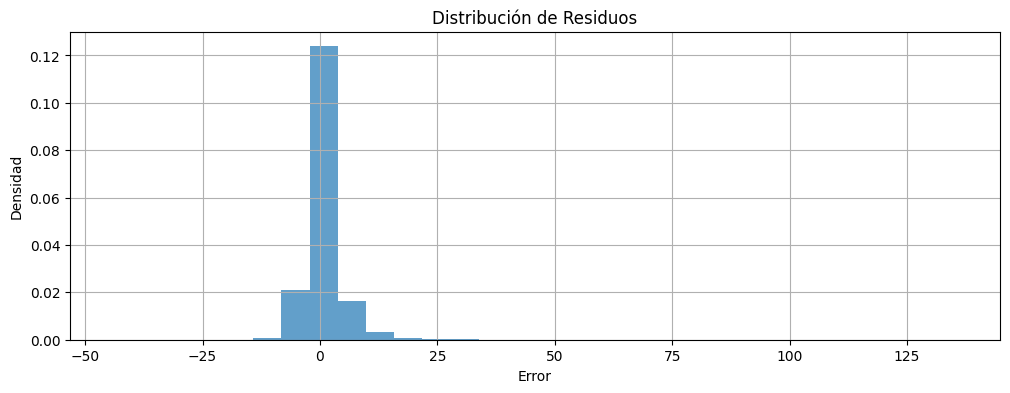


Optimizando LASSO


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 6.32, MAE: 3.66, R2: 0.42
  - Test  RMSE: 5.23, MAE: 2.89, R2: 0.57


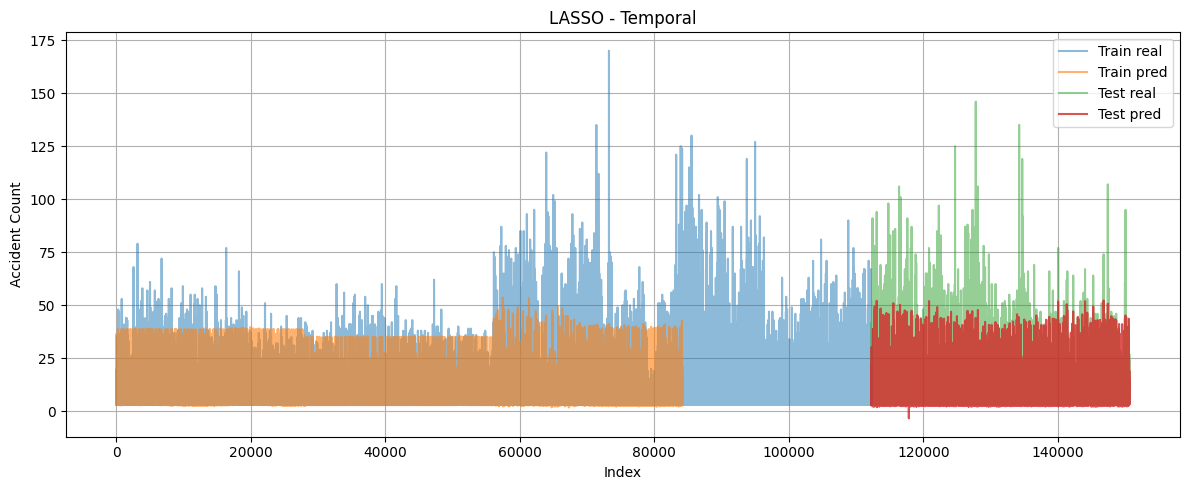

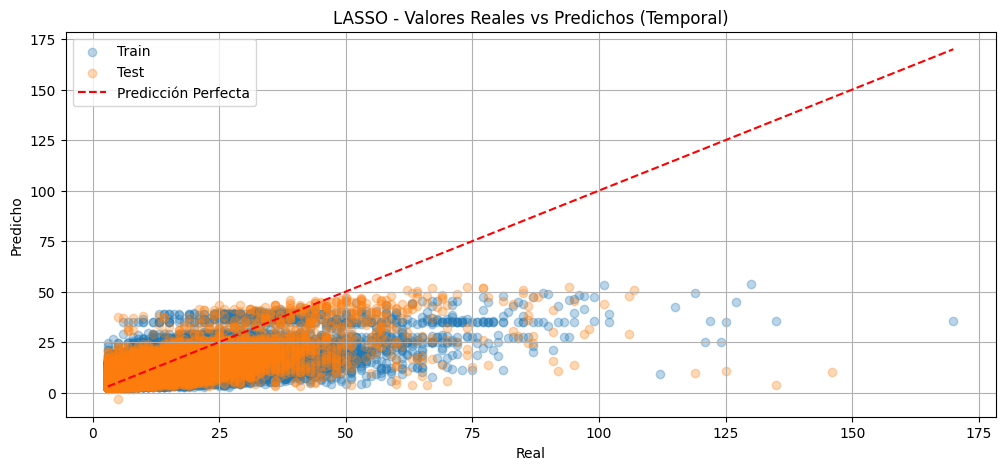

<Figure size 1200x400 with 0 Axes>

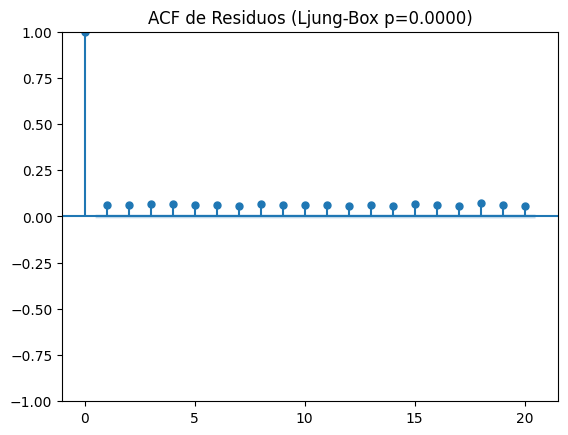

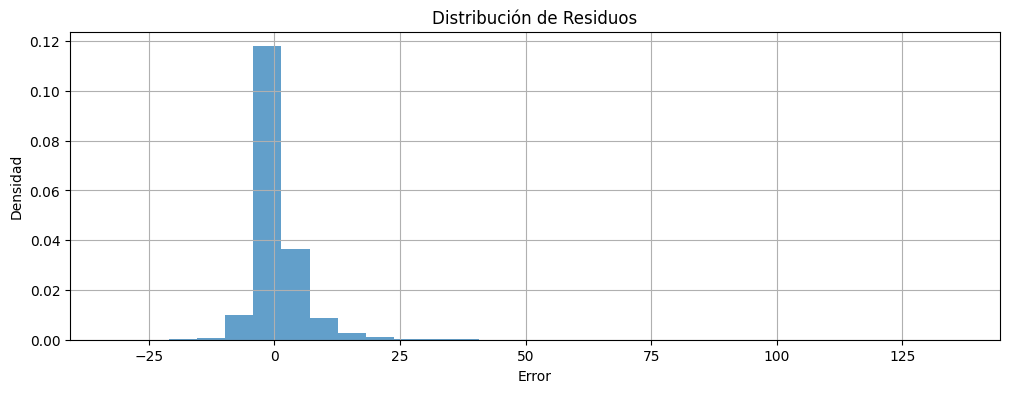

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 6.64, MAE: 4.34, R2: 0.27
  - Test  RMSE: 5.23, MAE: 2.89, R2: 0.57


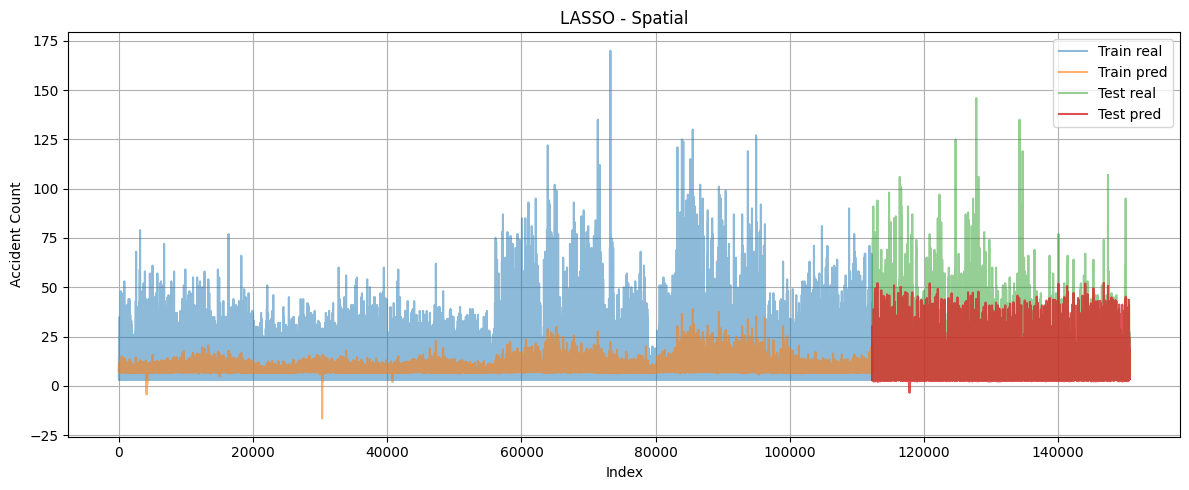

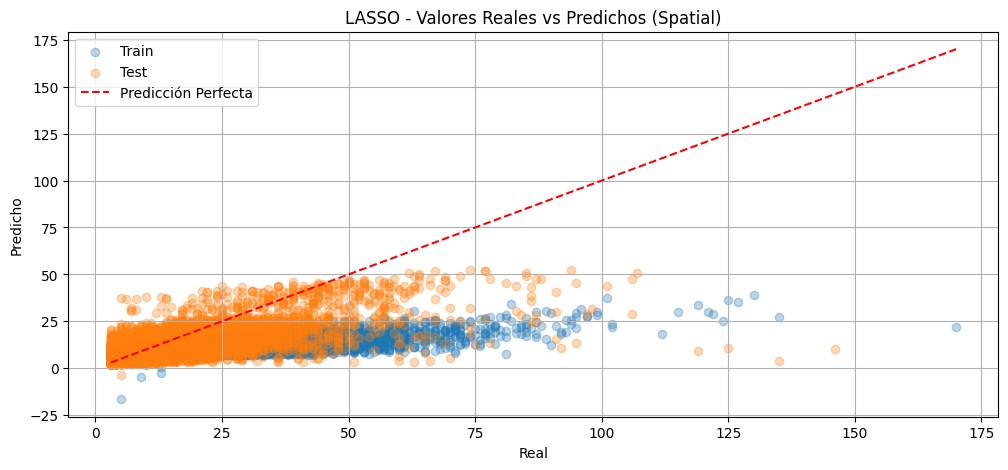

<Figure size 1200x400 with 0 Axes>

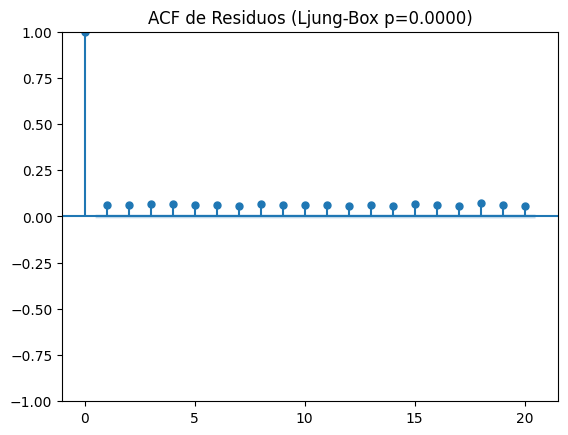

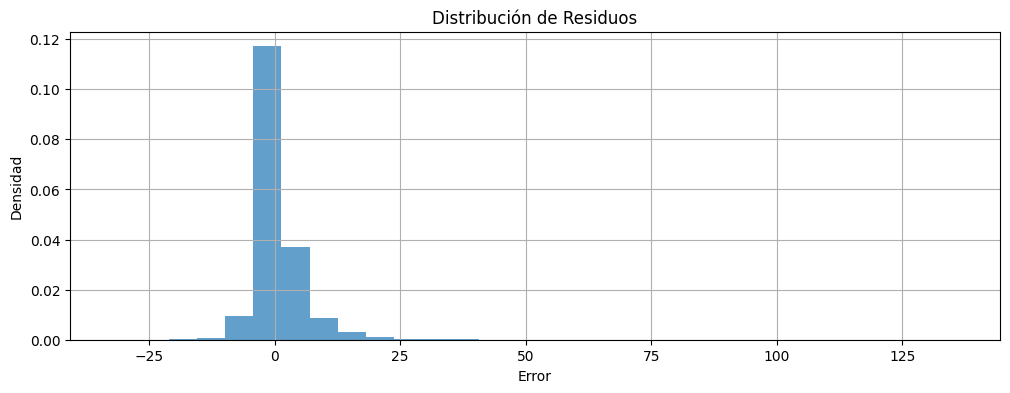


Optimizando RANDOM_FOREST


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



Explicación LIME para RANDOM_FOREST (Instancia 0):
Error en LIME: cannot import name 'display' from 'IPython.core.display' (c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\IPython\core\display.py)

→ Validación: TEMPORAL
  - Mejores parámetros: {'model__max_depth': None, 'model__n_estimators': 100}
  - Train RMSE: 3.77, MAE: 2.16, R2: 0.79
  - Test  RMSE: 3.90, MAE: 2.08, R2: 0.76


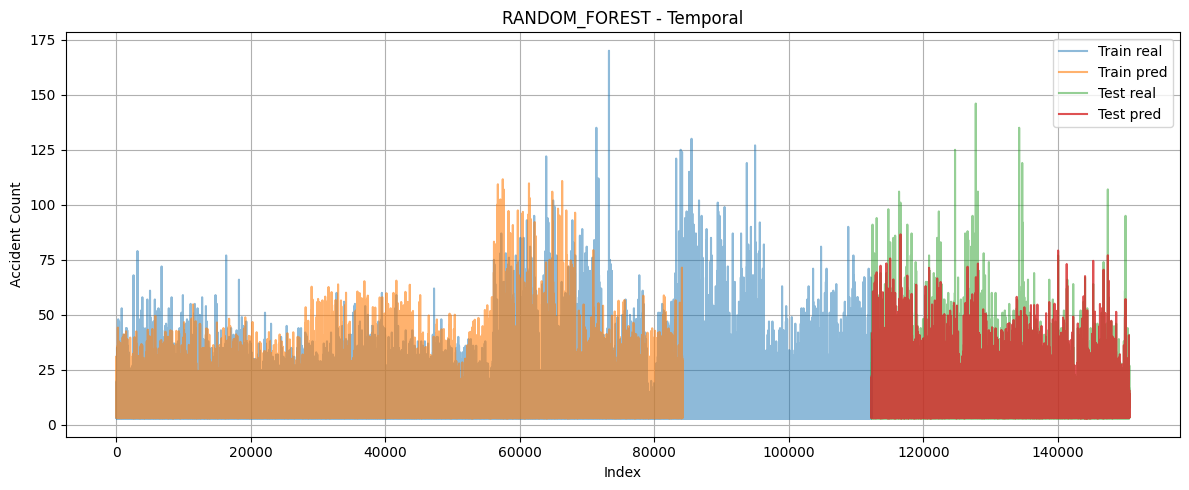

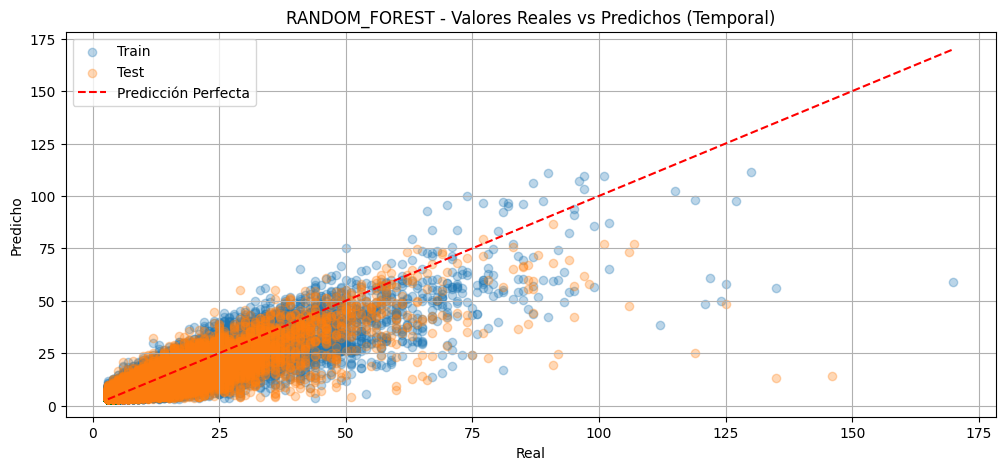

<Figure size 1200x400 with 0 Axes>

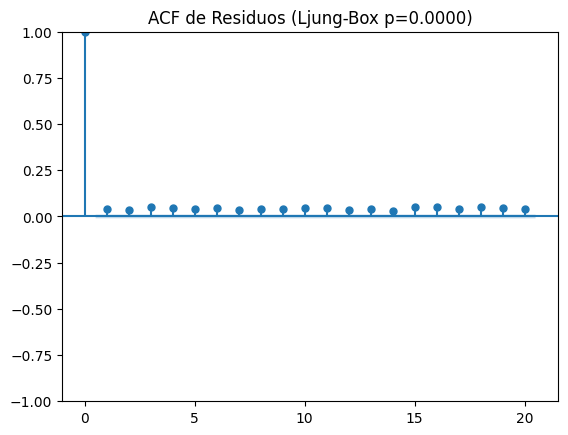

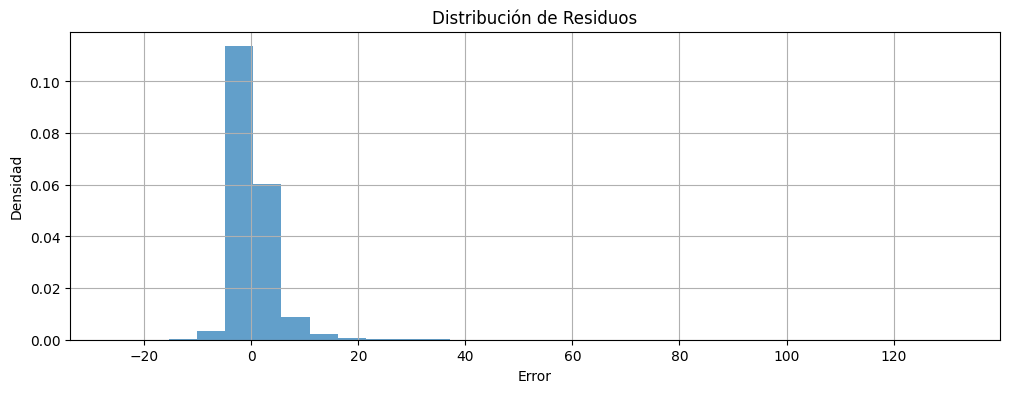

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



Explicación LIME para RANDOM_FOREST (Instancia 0):
Error en LIME: cannot import name 'display' from 'IPython.core.display' (c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\IPython\core\display.py)

→ Validación: SPATIAL
  - Mejores parámetros: {'model__max_depth': None, 'model__n_estimators': 100}
  - Train RMSE: 3.99, MAE: 2.36, R2: 0.74
  - Test  RMSE: 3.90, MAE: 2.08, R2: 0.76


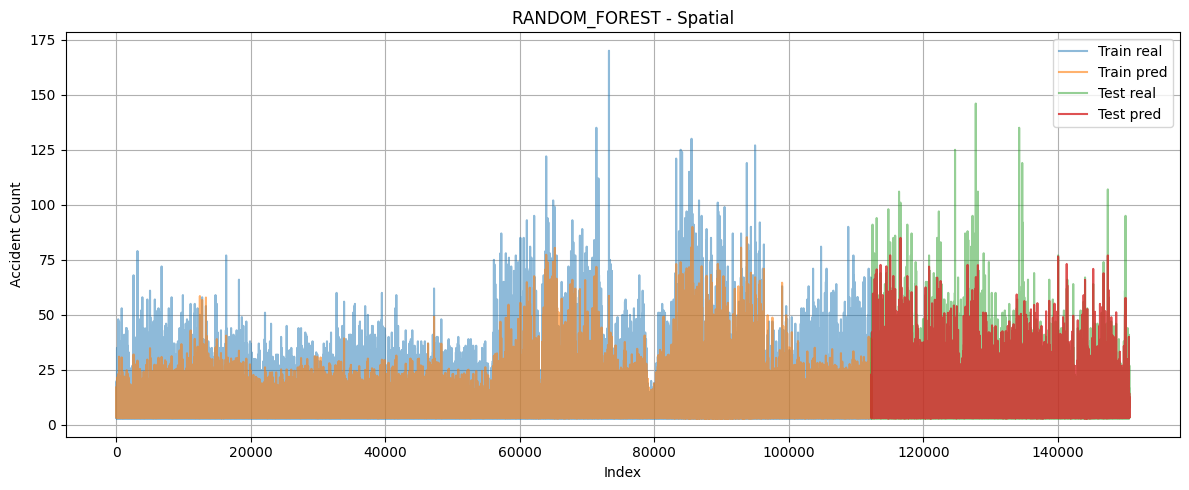

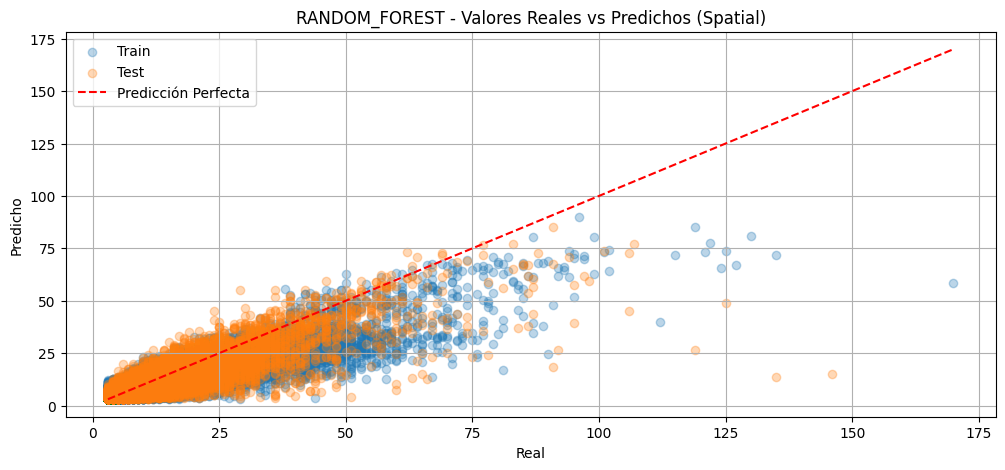

<Figure size 1200x400 with 0 Axes>

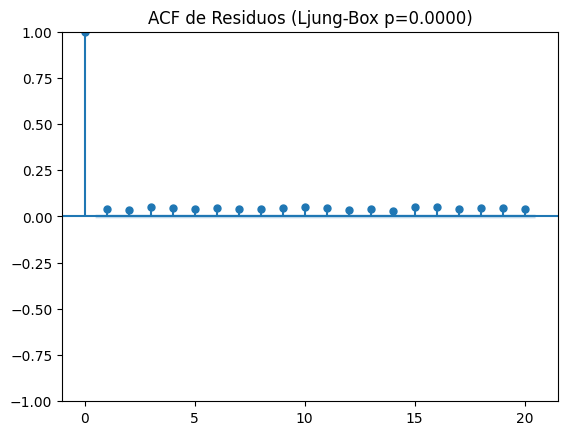

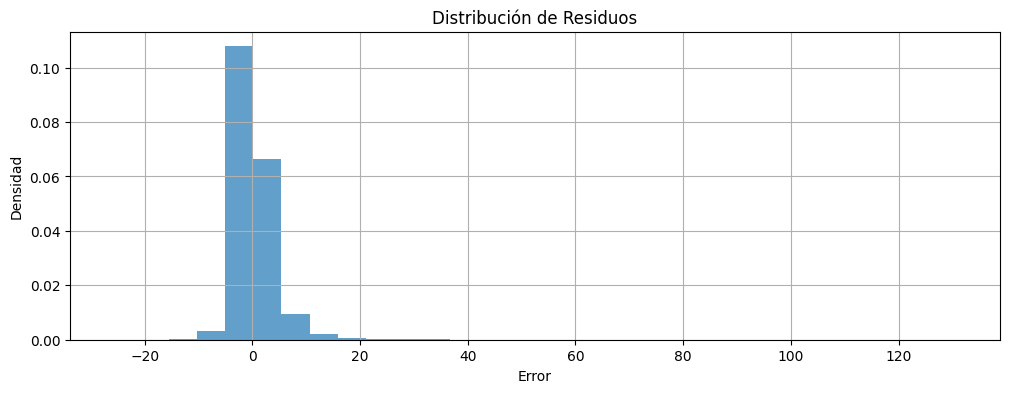


Optimizando XGBOOST


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:14:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:14:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:14:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(d


Explicación LIME para XGBOOST (Instancia 0):
Error en LIME: cannot import name 'display' from 'IPython.core.display' (c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\IPython\core\display.py)

→ Validación: TEMPORAL
  - Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  - Train RMSE: 3.63, MAE: 2.14, R2: 0.81
  - Test  RMSE: 3.84, MAE: 2.12, R2: 0.77


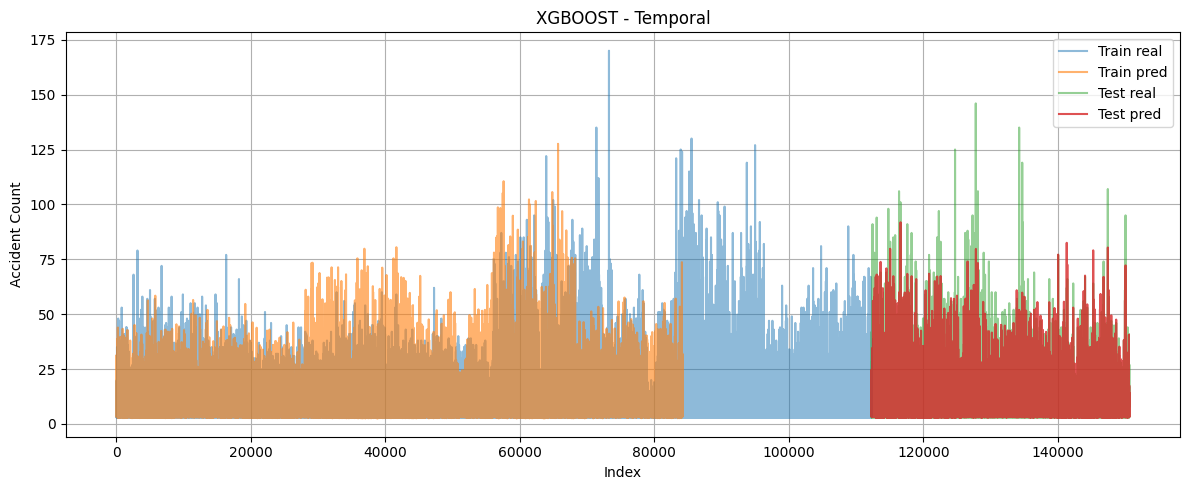

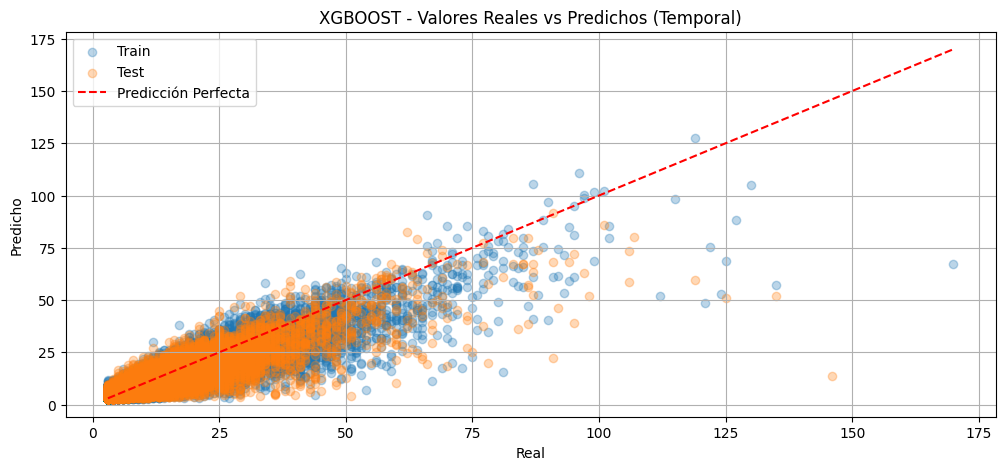

<Figure size 1200x400 with 0 Axes>

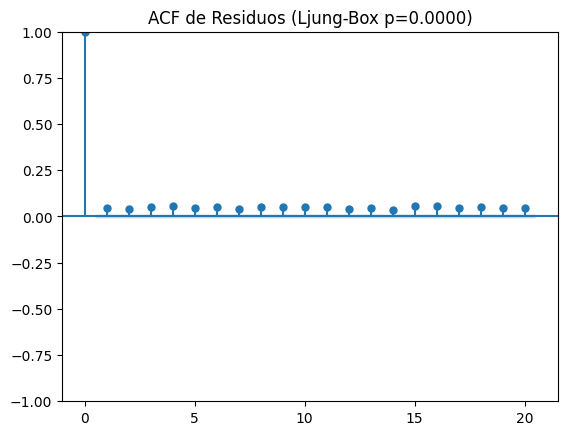

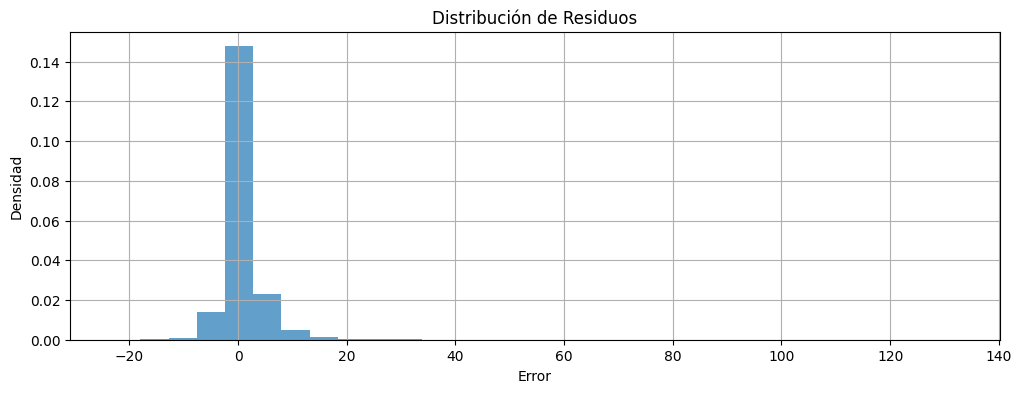

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:14:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Explicación LIME para XGBOOST (Instancia 0):
Error en LIME: cannot import name 'display' from 'IPython.core.display' (c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\IPython\core\display.py)

→ Validación: SPATIAL
  - Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  - Train RMSE: 3.73, MAE: 2.34, R2: 0.77
  - Test  RMSE: 3.84, MAE: 2.12, R2: 0.77


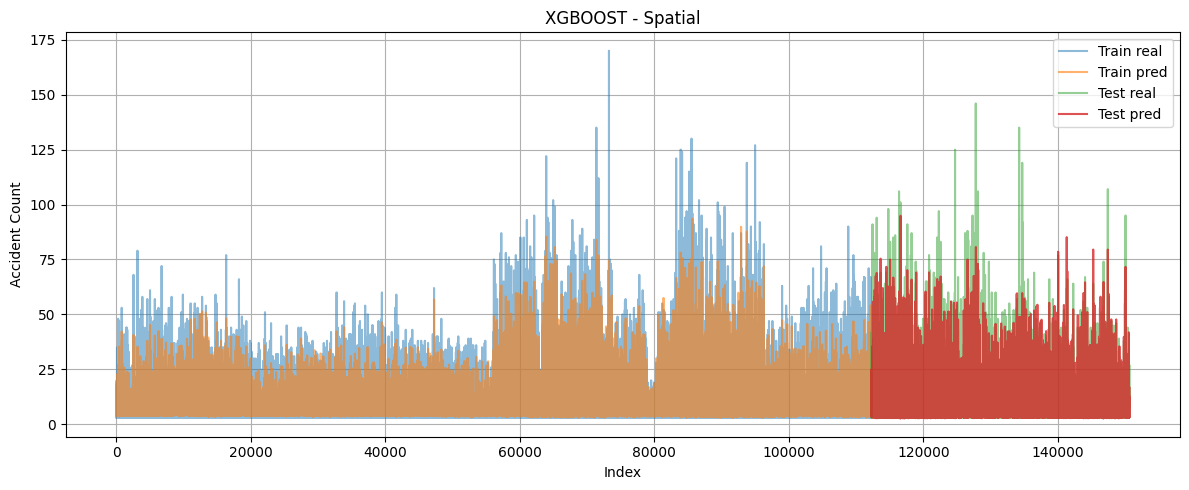

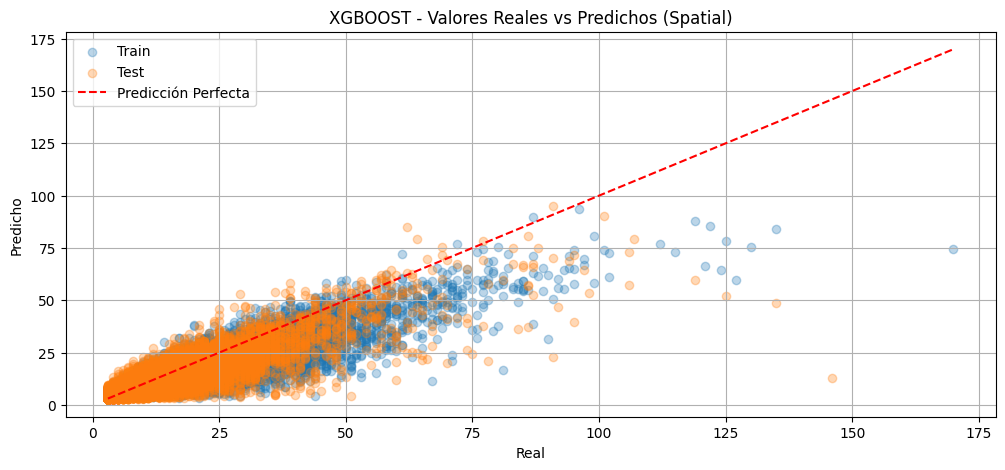

<Figure size 1200x400 with 0 Axes>

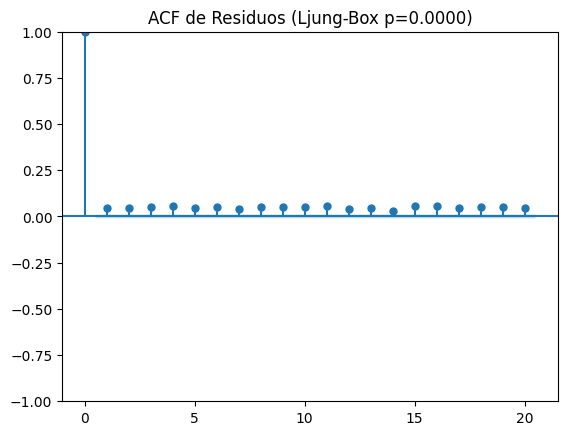

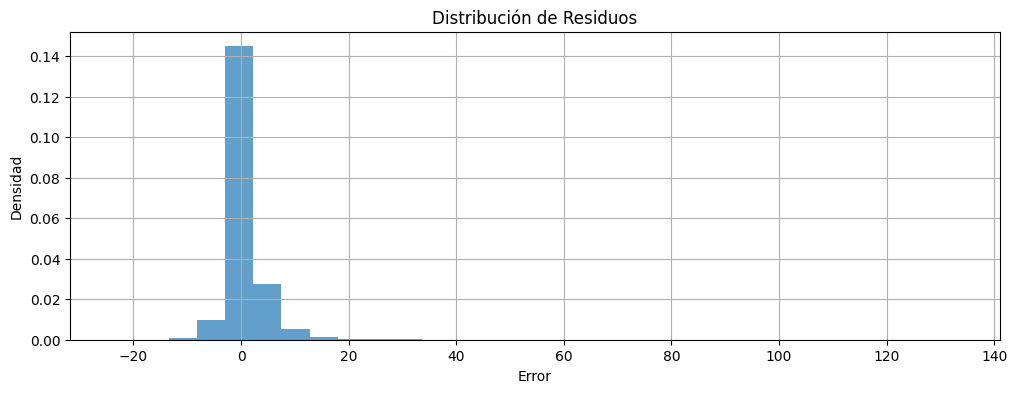


Optimizando SVR


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__C': 0.1, 'model__epsilon': 0.1, 'model__kernel': 'linear'}
  - Train RMSE: 4.69, MAE: 2.73, R2: 0.68
  - Test  RMSE: 4.40, MAE: 2.44, R2: 0.70


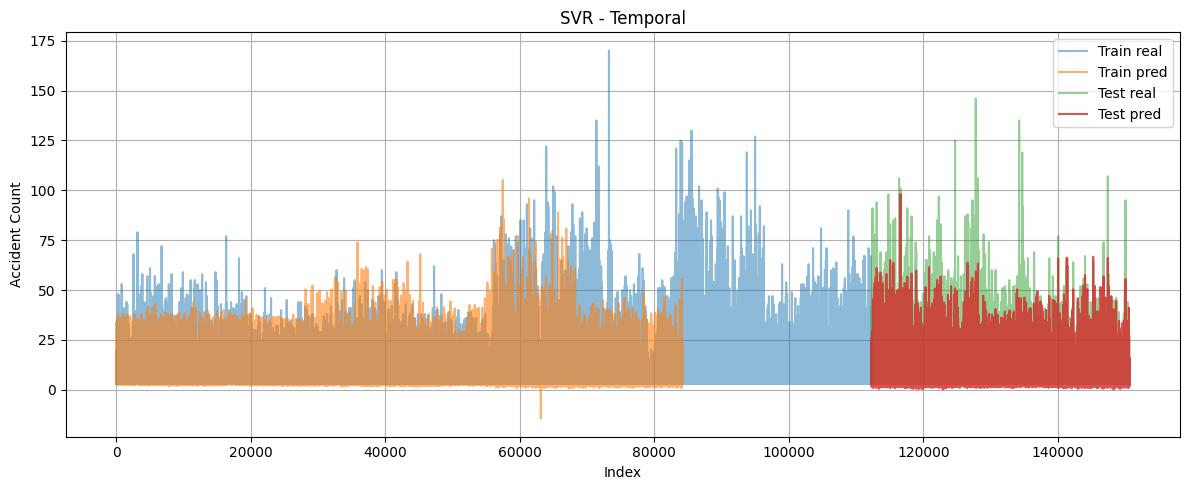

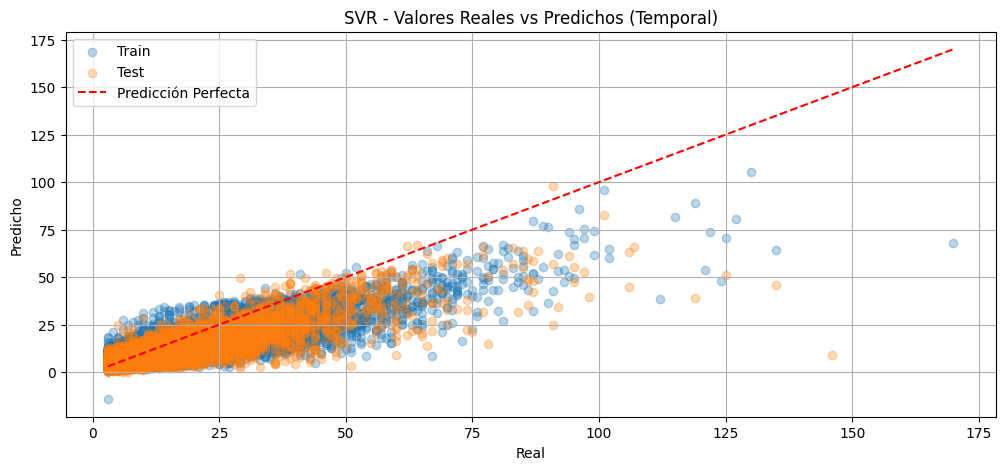

<Figure size 1200x400 with 0 Axes>

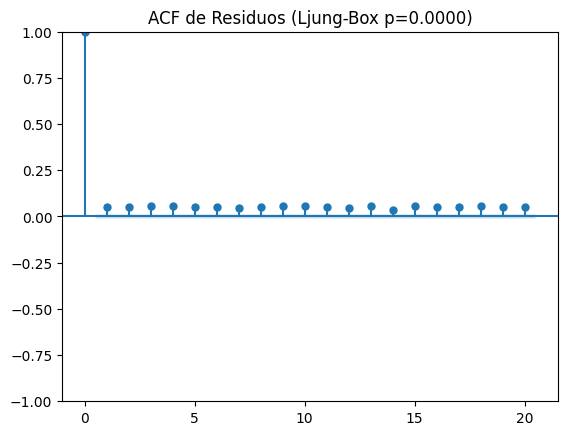

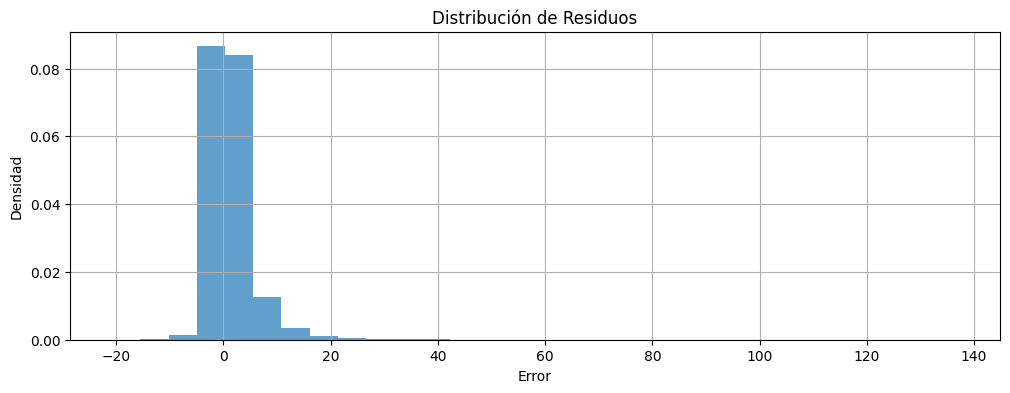

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__C': 0.1, 'model__epsilon': 0.1, 'model__kernel': 'linear'}
  - Train RMSE: 4.72, MAE: 2.91, R2: 0.63
  - Test  RMSE: 4.40, MAE: 2.44, R2: 0.70


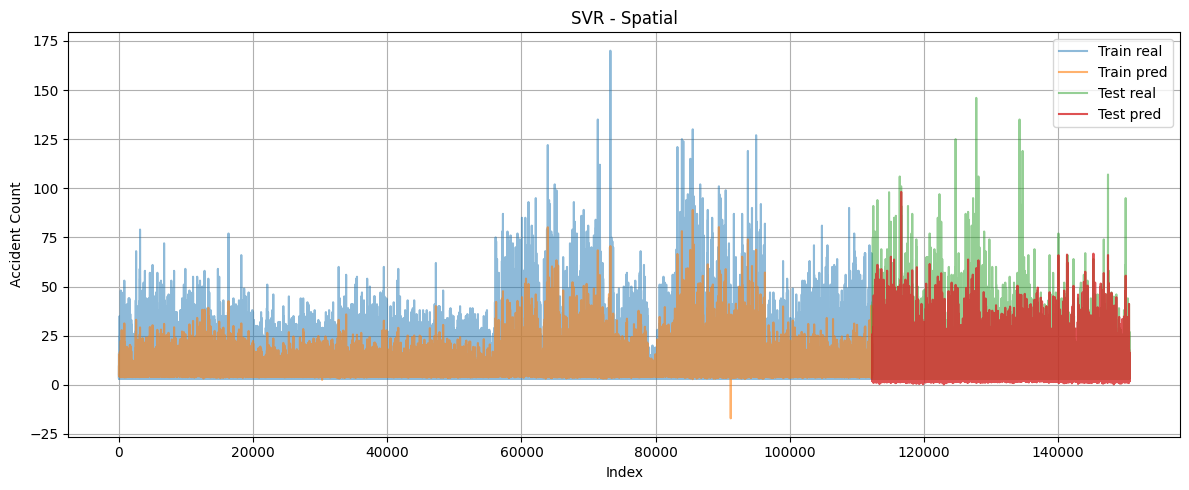

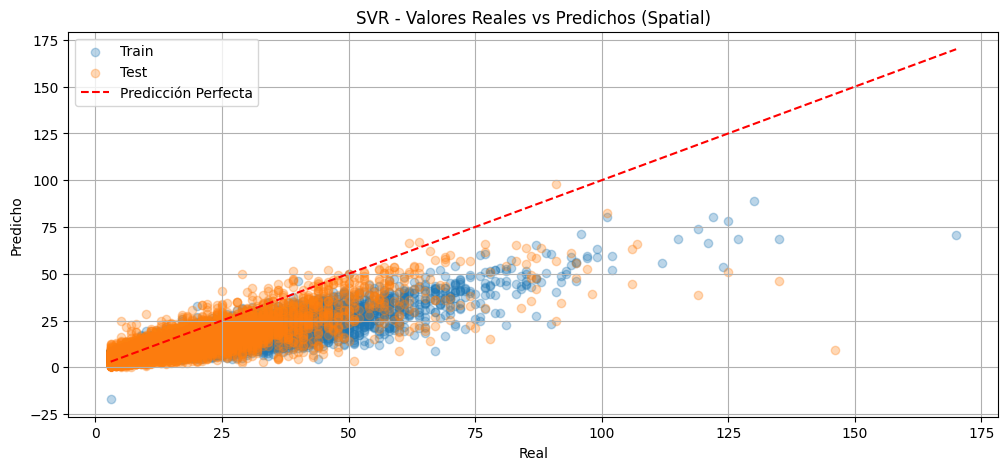

<Figure size 1200x400 with 0 Axes>

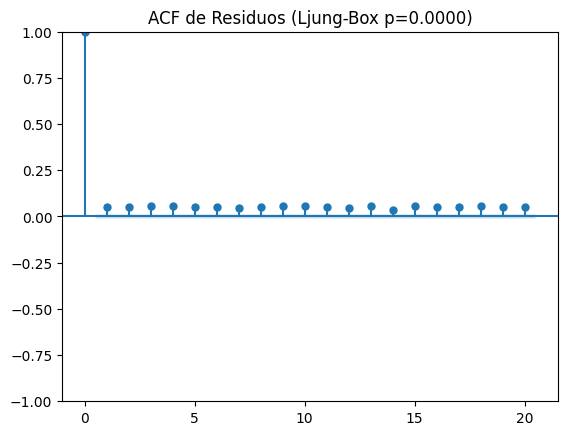

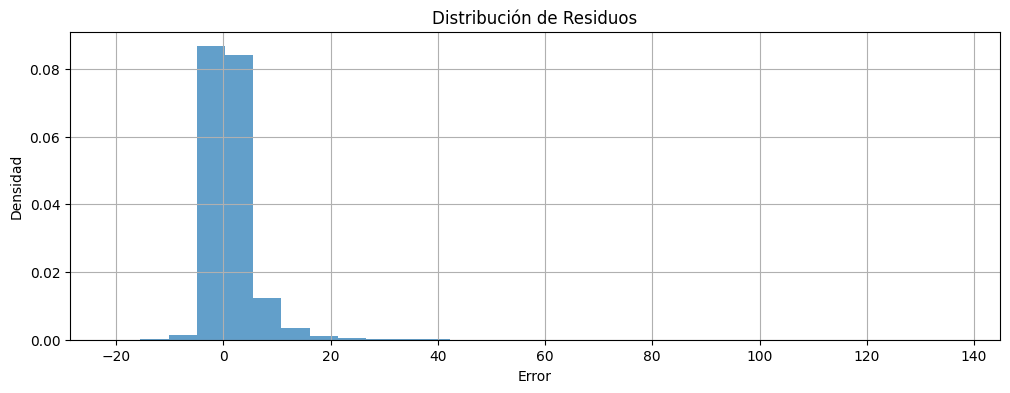

In [17]:
for model_name in pipelines:
    if model_name not in param_grids:
        continue

    print(f"\n{'='*40}\nOptimizando {model_name.upper()}\n{'='*40}")
    
    for mode, cv, group in [('temporal', tscv, None), ('spatial', group_kfold, groups_train)]:
        start = time.time()

        search = GridSearchCV(
            pipelines[model_name],
            param_grids[model_name],
            cv=cv,
            scoring=scorer,
            n_jobs=-1,
            verbose=0
        )

        if mode == 'spatial':
            search.fit(X_train, y_train, groups=group)
        else:
            search.fit(X_train, y_train)

        best_model = search.best_estimator_
        best_params = search.best_params_

        # Predicción en test
        y_pred_test = best_model.predict(X_test)

        # Predicción en train (implementación manual para temporal)
        if mode == 'spatial':
            y_pred_train = cross_val_predict(best_model, X_train, y_train, cv=group_kfold, groups=groups_train, n_jobs=-1)
        else:
            y_pred_train = np.full(y_train.shape[0], np.nan)
            for train_idx, test_idx in tscv.split(X_train):
                best_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
                y_pred_train[test_idx] = best_model.predict(X_train.iloc[test_idx])
            # Eliminar NaN de splits no cubiertos
            mask = ~np.isnan(y_pred_train)
            y_pred_train = y_pred_train[mask]
            y_train_filtered = y_train[mask]
        
        # ================== IMPLEMENTACIÓN DE LIME ==================
        if model_name in ['random_forest', 'xgboost']:  # Solo para modelos de árboles
            try:
                # Preprocesar datos para LIME
                X_train_processed = preprocessor.transform(X_train)
                explainer = lime.lime_tabular.LimeTabularExplainer(
                    training_data=X_train_processed,
                    feature_names=preprocessor.get_feature_names_out(),
                    mode="regression",
                    verbose=False
                )

                # Explicar una instancia de prueba
                instance_idx = 0
                instance_processed = preprocessor.transform(X_test.iloc[[instance_idx]])
                exp = explainer.explain_instance(
                    instance_processed[0], 
                    best_model.named_steps['model'].predict,
                    num_features=5
                )

                # Mostrar explicación
                print(f"\nExplicación LIME para {model_name.upper()} (Instancia {instance_idx}):")
                exp.show_in_notebook()
                
            except Exception as e:
                print(f"Error en LIME: {str(e)}")
        # ============================================================

        duration = round(time.time() - start, 2)
        
        # Métricas
        rmse_test = root_mean_squared_error(y_test, y_pred_test)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)

        if mode == 'spatial':
            rmse_train = root_mean_squared_error(y_train, y_pred_train)
            mae_train = mean_absolute_error(y_train, y_pred_train)
            r2_train = r2_score(y_train, y_pred_train)
        else:
            rmse_train = root_mean_squared_error(y_train_filtered, y_pred_train)
            mae_train = mean_absolute_error(y_train_filtered, y_pred_train)
            r2_train = r2_score(y_train_filtered, y_pred_train)

        # Pruebas estadísticas
        residuals = y_test - y_pred_test
        ljung_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
        jb_p = jarque_bera(residuals)[1]

        print(f"\n→ Validación: {mode.upper()}")
        print(f"  - Mejores parámetros: {best_params}")
        print(f"  - Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
        print(f"  - Test  RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        results.append({
            'Model': model_name.upper(),
            'Type': mode.capitalize(),
            'Train_RMSE': round(rmse_train, 2),
            'Train_MAE': round(mae_train, 2),
            'Train_R2': round(r2_train, 2),
            'Test_RMSE': round(rmse_test, 2),
            'Test_MAE': round(mae_test, 2),
            'Test_R2': round(r2_test, 2),
            'Duration (s)': duration,
            'Ljung-Box p-value': round(ljung_p, 4),
            'Jarque-Bera p-value': round(jb_p, 4)
        })

        # Gráfica
        plt.figure(figsize=(12, 5))
        plt.plot(y_train.values, label='Train real', alpha=0.5)
        plt.plot(y_pred_train, label='Train pred', alpha=0.6)
        plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), y_test.values, label='Test real', alpha=0.5)
        plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), y_pred_test, label='Test pred', alpha=0.8)
        plt.title(f'{model_name.upper()} - {mode.capitalize()}')
        plt.xlabel('Index')
        plt.ylabel('Accident Count')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # ================== NUEVAS VISUALIZACIONES ==================
        # 1. Gráfico de valores reales vs predichos
        plt.figure(figsize=(12, 5))
        
        # Definir datos según el modo de validación
        if mode == 'temporal':
            y_train_plot = y_train_filtered
            y_pred_train_plot = y_pred_train
        else:  # spatial
            y_train_plot = y_train
            y_pred_train_plot = y_pred_train
        
        # Scatter plot para train y test
        plt.scatter(y_train_plot, y_pred_train_plot, alpha=0.3, label='Train')
        plt.scatter(y_test, y_pred_test, alpha=0.3, label='Test')
        
        # Línea de referencia perfecta
        min_val = min(np.min(y_train_plot), np.min(y_test))
        max_val = max(np.max(y_train_plot), np.max(y_test))
        plt.plot([min_val, max_val], [min_val, max_val], '--r', label='Predicción Perfecta')
        
        plt.title(f'{model_name.upper()} - Valores Reales vs Predichos ({mode.capitalize()})')
        plt.xlabel('Real')
        plt.ylabel('Predicho')
        plt.legend()
        plt.grid(True)
        plt.show()
        # 2. ACF de residuos con p-value
        plt.figure(figsize=(12, 4))
        plot_acf(residuals, lags=20, alpha=0.05)
        plt.title(f'ACF de Residuos (Ljung-Box p={ljung_p:.4f})')
        plt.show()

        # 3. Histograma de residuos
        plt.figure(figsize=(12, 4))
        plt.hist(residuals, bins=30, density=True, alpha=0.7)
        plt.title('Distribución de Residuos')
        plt.xlabel('Error')
        plt.ylabel('Densidad')
        plt.grid(True)
        plt.show()
        
        
        

In [18]:
# Mostrar resultados finales
results_df = pd.DataFrame(results)
print("\n\nRESULTADOS FINALES:")
print(results_df)



RESULTADOS FINALES:
            Model      Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  \
0             KNN  Temporal        6.53       3.80      0.38       6.09   
1             KNN   Spatial        7.63       4.61      0.04       6.07   
2           RIDGE  Temporal        3.55       2.25      0.82       4.03   
3           RIDGE   Spatial        3.67       2.45      0.78       4.03   
4           LASSO  Temporal        6.32       3.66      0.42       5.23   
5           LASSO   Spatial        6.64       4.34      0.27       5.23   
6   RANDOM_FOREST  Temporal        3.77       2.16      0.79       3.90   
7   RANDOM_FOREST   Spatial        3.99       2.36      0.74       3.90   
8         XGBOOST  Temporal        3.63       2.14      0.81       3.84   
9         XGBOOST   Spatial        3.73       2.34      0.77       3.84   
10            SVR  Temporal        4.69       2.73      0.68       4.40   
11            SVR   Spatial        4.72       2.91      0.63       4.40   

  

In [19]:
# Mostrar solo la fila 7 (índice 7)
print(results_df.iloc[[7]].to_string(index=False))

        Model    Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2  Duration (s)  Ljung-Box p-value  Jarque-Bera p-value
RANDOM_FOREST Spatial        3.99       2.36      0.74        3.9      2.08     0.76        244.43                0.0                  0.0
